In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

pl.Config.set_tbl_rows(15)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


polars.config.Config

In [2]:
# Configuration and paths
corr_method = 'spearman'
trait_type = 'quantitative'
variant_class = 'intronic'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac


759.292

In [3]:
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""conservation""","""gpn_score""","""#942c80""","""GPN-MSA""",-1
"""conservation""","""zooverphylop""","""#6a1c81""","""Zoonomia vertebrate PhyloP""",1
"""conservation""","""verphylop""","""#440154""","""Vertebrate PhyloP""",1
"""naive""","""relative_cds_position""","""#b5de2b""","""Relative CDS Position""",-1
…,…,…,…,…


In [6]:
# anno = pl.scan_parquet(f"/home/dnanexus/data_dir/variant_classes/genebass1e6_genes_{variant_class.lower()}_variants_annotations.parquet")
anno = pl.scan_parquet(f"/home/dnanexus/data_dir/genebass1e6_genes_10kb_allvars_annotated_250925.parquet")

cols = anno.collect_schema().names()
rename_map = {}
for c in cols:
    new = c.lower()
    if new.startswith('cadd_') and (not new.startswith('cadd_raw') and not new.startswith('cadd_phred')):
        new = new[len('cadd_'):]
    rename_map[c] = new

anno = anno.rename(rename_map)
anno.head().collect()

chrom,pos,ref,alt,id,col,gene,distance,polyphen,cadd_raw,am_pathogenicity,spliceai_delta_score,consequence_3_prime_utr_variant,consequence_5_prime_utr_variant,consequence_nmd_transcript_variant,consequence_coding_sequence_variant,consequence_downstream_gene_variant,consequence_frameshift_variant,consequence_inframe_deletion,consequence_inframe_insertion,consequence_intergenic_variant,consequence_intron_variant,consequence_missense_variant,consequence_non_coding_transcript_exon_variant,consequence_non_coding_transcript_variant,consequence_protein_altering_variant,consequence_splice_acceptor_variant,consequence_splice_donor_5th_base_variant,consequence_splice_donor_region_variant,consequence_splice_donor_variant,consequence_splice_polypyrimidine_tract_variant,consequence_splice_region_variant,consequence_start_lost,consequence_start_retained_variant,consequence_stop_gained,consequence_stop_lost,consequence_stop_retained_variant,…,sngl10000bp_is_nan,ensembleregulatoryfeature_is_nan,dbscsnv-ada_score_is_nan,dbscsnv-rf_score_is_nan,remapoverlaptf_is_nan,remapoverlapcl_is_nan,esmscoremissense_is_nan,esmscoreinframe_is_nan,esmscoreframeshift_is_nan,regseq0_is_nan,regseq1_is_nan,regseq2_is_nan,regseq3_is_nan,regseq4_is_nan,regseq5_is_nan,regseq6_is_nan,regseq7_is_nan,aparent2_is_nan,zoopriphylop_is_nan,zooverphylop_is_nan,zoorocc_is_nan,zoouce_is_nan,roulette-filter_is_nan,roulette-mr_is_nan,roulette-ar_is_nan,cadd_rawscore_is_nan,cadd_phred_is_nan,tss,strand,gene_length,gene_name,dist_to_tss,abexp_max,abexp_min,promoterai_abs,promoterai_over,promoterai_under
str,i32,str,str,str,i32,str,i32,f32,f32,f32,f32,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i64,cat,i64,str,i64,f64,f64,f32,f32,f32
"""chr2""",134144266,"""C""","""T""","""chr2:134144266:C:T""",11108971,"""ENSG00000152127""",0,0.0,0.955524,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,1,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,134119982,"""+""",334640,"""MGAT5""",24284,-0.011144,-0.012463,0.0,0.0,0.0
"""chr2""",134192587,"""C""","""T""","""chr2:134192587:C:T""",11127058,"""ENSG00000152127""",0,0.0,0.25085,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,134119982,"""+""",334640,"""MGAT5""",72605,-0.00487,-0.006189,0.0,0.0,0.0
"""chr2""",134389573,"""T""","""C""","""chr2:134389573:T:C""",11199699,"""ENSG00000152127""",0,0.0,1.25828,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,134119982,"""+""",334640,"""MGAT5""",269591,-0.011792,-0.013111,0.0,0.0,0.0
"""chr2""",127525503,"""G""","""A""","""chr2:127525503:G:A""",11084322,"""ENSG00000163166""",0,0.0,0.395322,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,127526886,"""-""",90681,"""IWS1""",1383,0.003182,-0.006438,0.0,0.0,0.0
"""chr2""",134155422,"""C""","""T""","""chr2:134155422:C:T""",11112693,"""ENSG00000152127""",0,0.0,0.240848,0.0,0.04,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,134119982,"""+""",334640,"""MGAT5""",35440,-0.00487,-0.006189,0.0,0.0,0.0


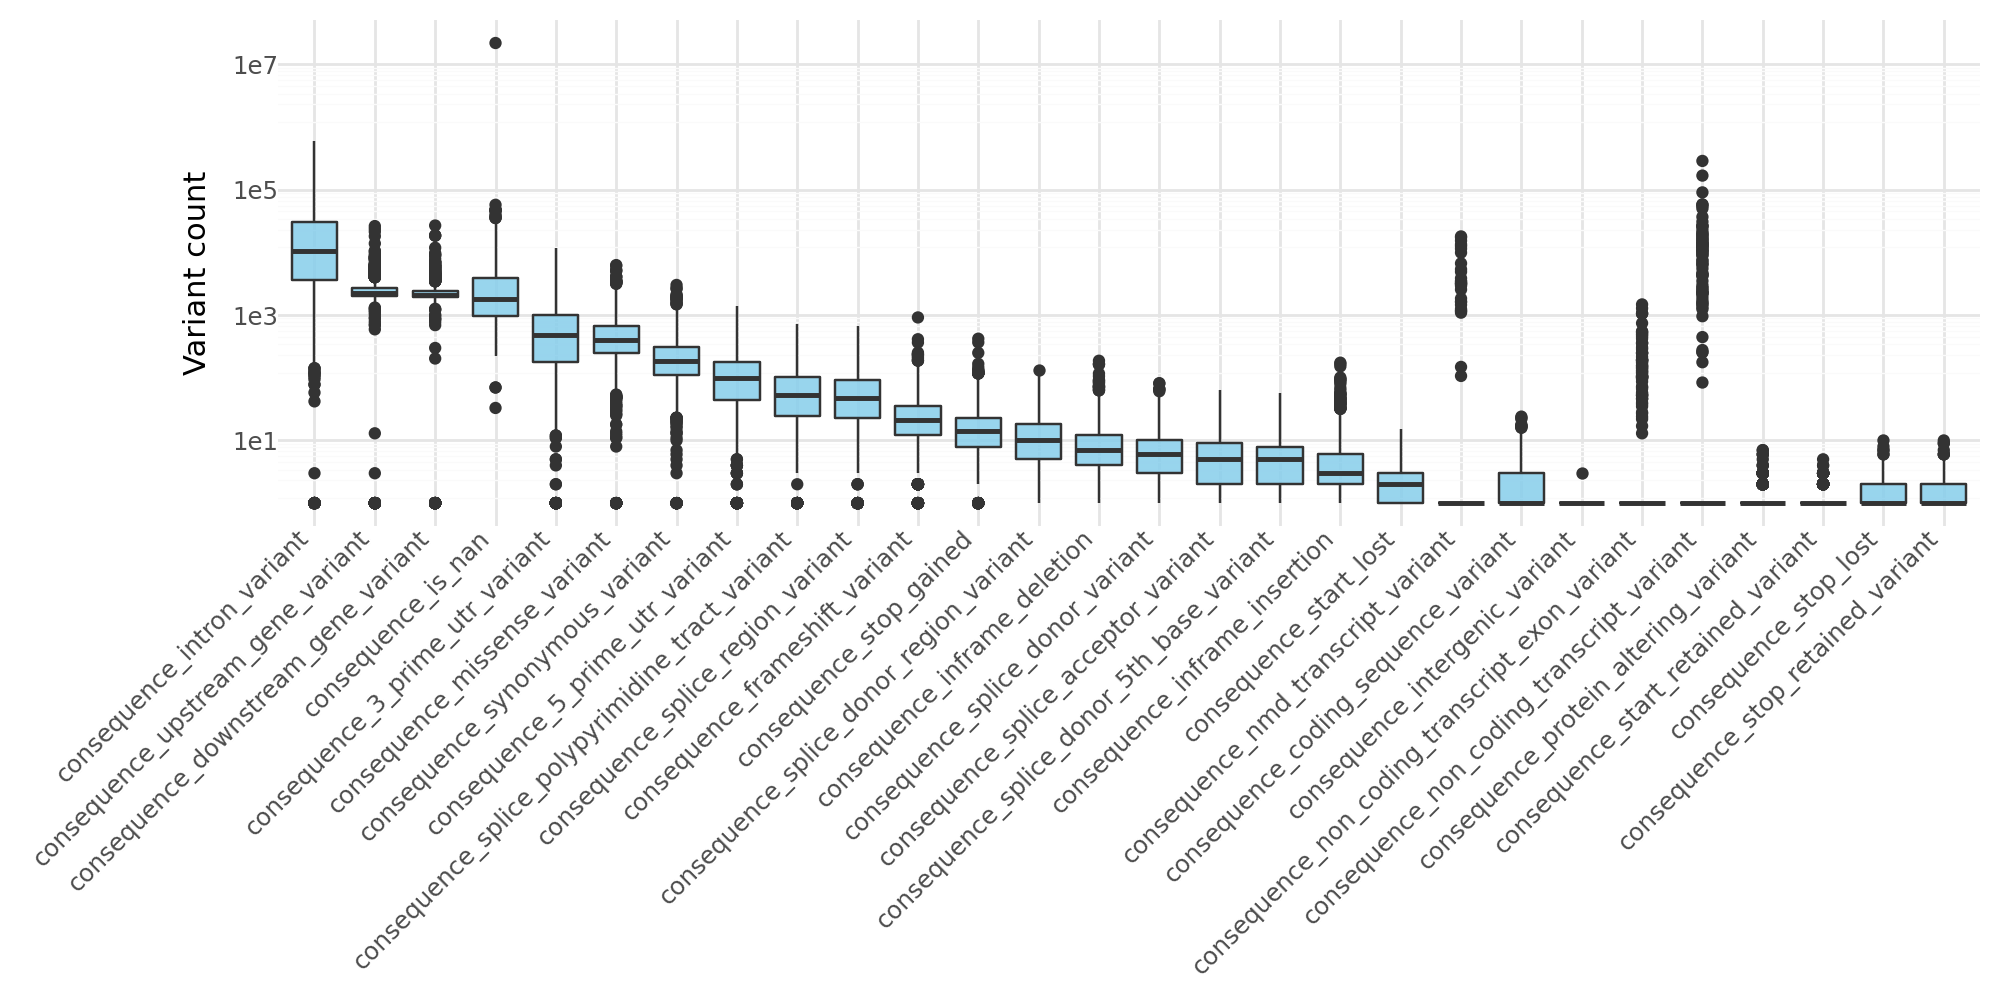

In [8]:
cons_annos = [c for c in anno.collect_schema().names() if c.startswith('consequence_')]

agg_exprs = [pl.col(c).sum() for c in cons_annos]

# Group by 'region' and apply the aggregations
gene_counts = (
    anno.group_by('region')
    .agg(agg_exprs)
    .collect(engine='streaming')
    .unpivot(index='region', variable_name='consequence', value_name='count')
    .with_columns(imputed_count=pl.col('count')+1) # Allows log scale plotting
)

med_counts = (
    gene_counts
    .group_by('consequence')
    .agg(pl.col('imputed_count').median().alias('median_count'))
)

gene_counts = (
    gene_counts
    .join(med_counts, on='consequence', how='left')
    .sort('median_count', descending=True)
    .to_pandas()
)

gene_counts['consequence'] = pd.Categorical(gene_counts['consequence'], categories=gene_counts['consequence'].unique().tolist(), ordered=True)

(
    ggplot(gene_counts, aes(x='consequence', y='imputed_count')) +
    geom_boxplot(fill='skyblue', alpha=0.85) +
    theme_minimal() +
    labs(x='', y='Variant count') +
    scale_x_discrete(limits=gene_counts['consequence'].cat.categories.tolist()) +
    scale_y_log10() +
    theme(axis_text_x=element_text(rotation=45, hjust=1), figure_size=(10, 5))
)

# Score distributions across regions

In [34]:
gene_name = "LDLR"
gene_vars = anno.filter(pl.col('gene_name')==gene_name).collect()
gene_vars

chrom,pos,ref,alt,id,col,gene,distance,polyphen,cadd_raw,am_pathogenicity,spliceai_delta_score,consequence_3_prime_utr_variant,consequence_5_prime_utr_variant,consequence_nmd_transcript_variant,consequence_coding_sequence_variant,consequence_downstream_gene_variant,consequence_frameshift_variant,consequence_inframe_deletion,consequence_inframe_insertion,consequence_intergenic_variant,consequence_intron_variant,consequence_missense_variant,consequence_non_coding_transcript_exon_variant,consequence_non_coding_transcript_variant,consequence_protein_altering_variant,consequence_splice_acceptor_variant,consequence_splice_donor_5th_base_variant,consequence_splice_donor_region_variant,consequence_splice_donor_variant,consequence_splice_polypyrimidine_tract_variant,consequence_splice_region_variant,consequence_start_lost,consequence_start_retained_variant,consequence_stop_gained,consequence_stop_lost,consequence_stop_retained_variant,…,sngl10000bp_is_nan,ensembleregulatoryfeature_is_nan,dbscsnv-ada_score_is_nan,dbscsnv-rf_score_is_nan,remapoverlaptf_is_nan,remapoverlapcl_is_nan,esmscoremissense_is_nan,esmscoreinframe_is_nan,esmscoreframeshift_is_nan,regseq0_is_nan,regseq1_is_nan,regseq2_is_nan,regseq3_is_nan,regseq4_is_nan,regseq5_is_nan,regseq6_is_nan,regseq7_is_nan,aparent2_is_nan,zoopriphylop_is_nan,zooverphylop_is_nan,zoorocc_is_nan,zoouce_is_nan,roulette-filter_is_nan,roulette-mr_is_nan,roulette-ar_is_nan,cadd_rawscore_is_nan,cadd_phred_is_nan,tss,strand,gene_length,gene_name,dist_to_tss,abexp_max,abexp_min,promoterai_abs,promoterai_over,promoterai_under
str,i32,str,str,str,i32,str,i32,f32,f32,f32,f32,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i64,cat,i64,str,i64,f64,f64,f32,f32,f32
"""chr19""",11093738,"""G""","""A""","""chr19:11093738:G:A""",81569835,"""ENSG00000130164""",0,0.0,0.372048,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,11089461,"""+""",44360,"""LDLR""",4277,-0.005501,-0.005877,0.0,0.0,0.0
"""chr19""",11110949,"""G""","""A""","""chr19:11110949:G:A""",81577106,"""ENSG00000130164""",0,0.0,-0.889739,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,1,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,11089461,"""+""",44360,"""LDLR""",21488,-0.005501,-0.005877,0.0,0.0,0.0
"""chr19""",11137687,"""A""","""C""","""chr19:11137687:A:C""",81588832,"""ENSG00000130164""",3867,0.0,-0.0706,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,11089461,"""+""",44360,"""LDLR""",48226,0.002469,0.002093,0.0,0.0,0.0
"""chr19""",11131908,"""T""","""C""","""chr19:11131908:T:C""",81585996,"""ENSG00000130164""",0,0.0,-0.358473,0.0,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,11089461,"""+""",44360,"""LDLR""",42447,-0.005229,-0.005605,0.0,0.0,0.0
"""chr19""",11099670,"""C""","""G""","""chr19:11099670:C:G""",81572185,"""ENSG00000130164""",0,0.0,-0.016461,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,11089461,"""+""",44360,"""LDLR""",10209,-0.005501,-0.005877,0.0,0.0,0.0
"""chr19""",11114441,"""G""","""T""","""chr19:11114441:G:T""",81578659,"""ENSG00000130164""",0,0.0,0.608911,0.0,0.04,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,11089461,"""+""",44360,"""LDLR""",24980,-0.005303,-0.005679,0.0,0.0,0.0
"""chr19""",11136489,"""G""","""C""","""chr19:11136489:G:C""",81588268,"""ENSG00000130164""",2669,0.0,-0.119662,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,1,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,11089461,"""+""",44360,"""LDLR""",47028,0.002469,0.002093,0.0,0.0,0.0
"""chr19""",11116843,"""C""","""A""","""chr19:11116843:C:A""",81579676,"""ENSG00000130164""",0,0.0,0.621842,0.0,0

In [35]:
anno_list = ['cadd_raw', 'gpn_score']

cons_annos = [c for c in anno.collect_schema().names() if c.startswith('consequence_')]
anno_cons_dist_list = []
for c in cons_annos:
    anno_cons_dist_list.append(
        gene_vars
        .filter(pl.col(c) == 1)
        .select(['chrom', 'pos', 'ref', 'alt', 'id', 'region', 'gene_name'] + anno_list)
        .with_columns(consequence=pl.lit(c))
    )

anno_cons_dist = pl.concat(anno_cons_dist_list)
anno_cons_dist

chrom,pos,ref,alt,id,region,gene_name,cadd_raw,gpn_score,consequence
str,i32,str,str,str,str,str,f32,f32,str
"""chr19""",11131908,"""T""","""C""","""chr19:11131908:T:C""","""ENSG00000130164""","""LDLR""",-0.358473,-1.16,"""consequence_3_prime_utr_varian…"
"""chr19""",11133105,"""G""","""A""","""chr19:11133105:G:A""","""ENSG00000130164""","""LDLR""",0.217021,-0.57,"""consequence_3_prime_utr_varian…"
"""chr19""",11131891,"""G""","""C""","""chr19:11131891:G:C""","""ENSG00000130164""","""LDLR""",-1.008828,-0.67,"""consequence_3_prime_utr_varian…"
"""chr19""",11132032,"""C""","""A""","""chr19:11132032:C:A""","""ENSG00000130164""","""LDLR""",-0.225037,-1.04,"""consequence_3_prime_utr_varian…"
"""chr19""",11133170,"""C""","""T""","""chr19:11133170:C:T""","""ENSG00000130164""","""LDLR""",0.125201,-0.11,"""consequence_3_prime_utr_varian…"
"""chr19""",11133657,"""T""","""G""","""chr19:11133657:T:G""","""ENSG00000130164""","""LDLR""",0.145205,-1.5,"""consequence_3_prime_utr_varian…"
"""chr19""",11133617,"""A""","""T""","""chr19:11133617:A:T""","""ENSG00000130164""","""LDLR""",-0.199489,-1.34,"""consequence_3_prime_utr_varian…"
"""chr19""",11132770,"""T""","""C""","""chr19:11132770:T:C""","""ENSG00000130164""","""LDLR""",0.422421,-0.81,"""consequence_3_prime_utr_varian…"
…,…,…,…,…,…,…,…,…,…


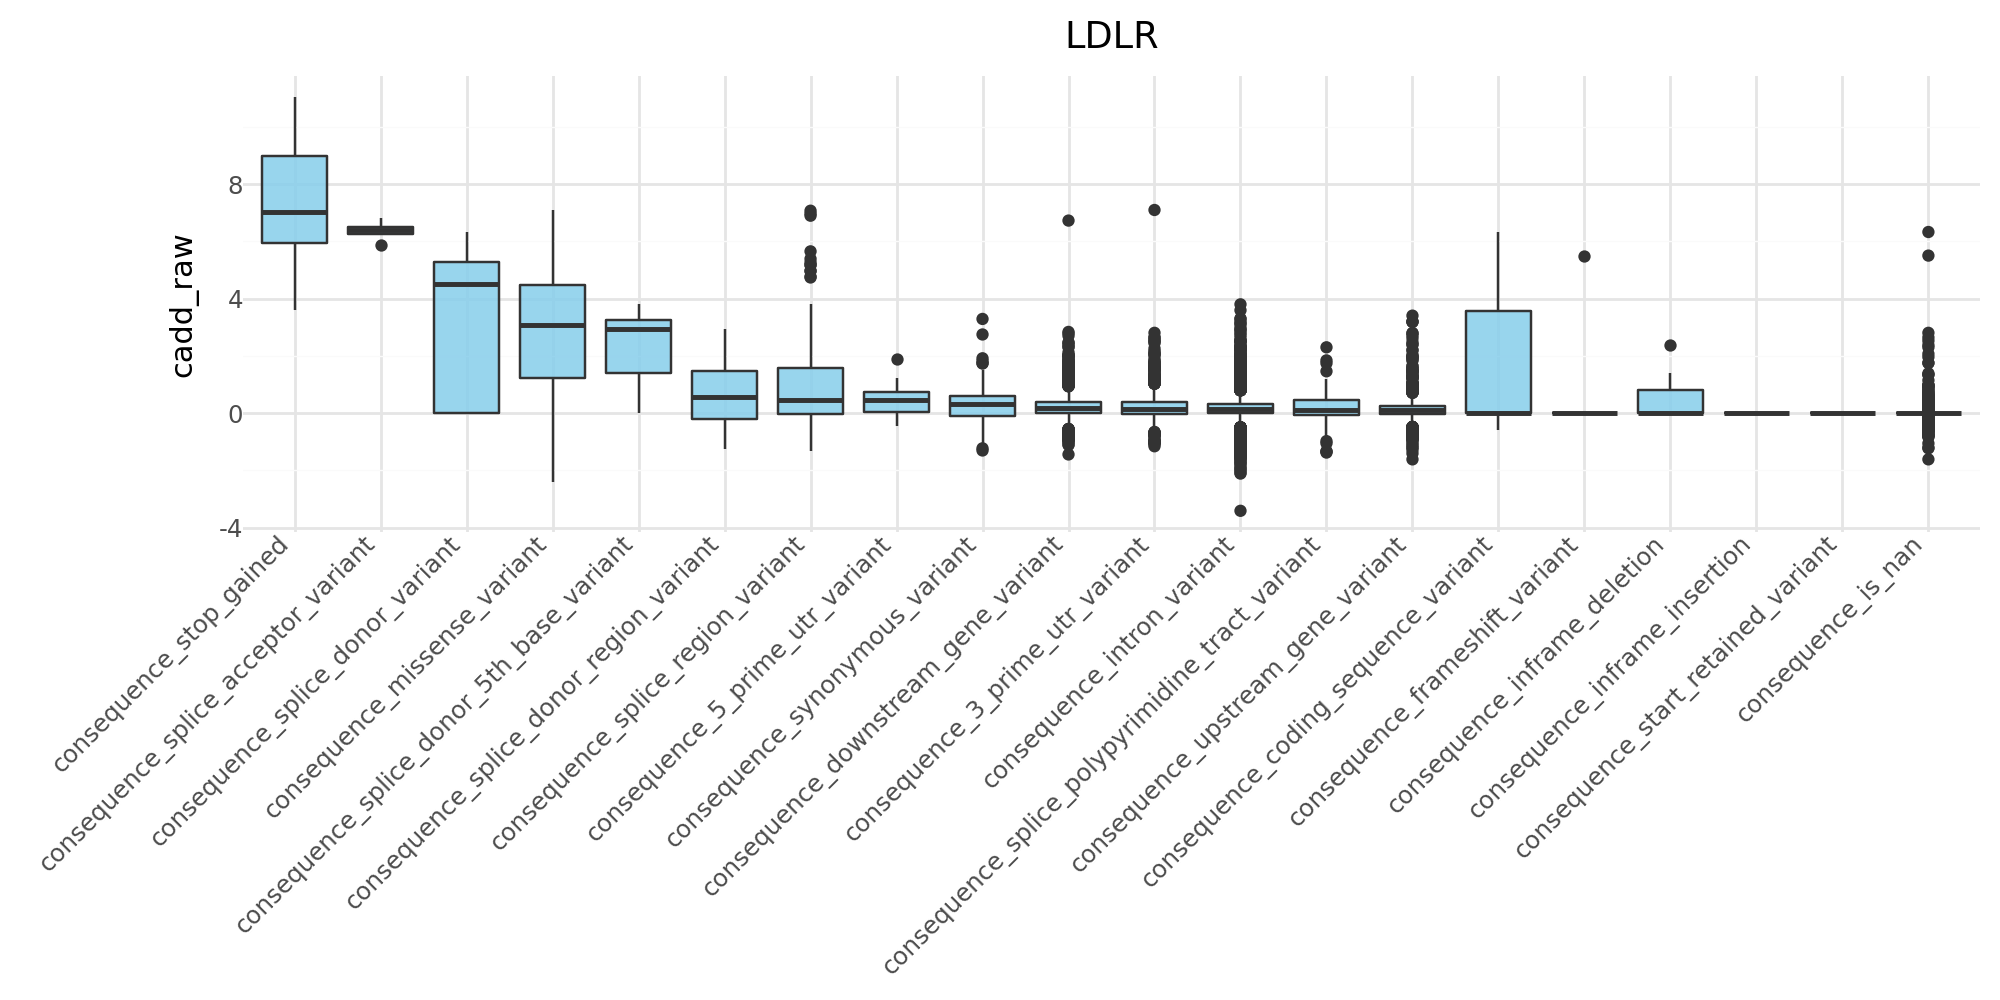

In [40]:
anno2plot = 'cadd_raw'

med_counts = (
    anno_cons_dist
    .group_by('consequence')
    .agg(pl.col(anno2plot).median().alias(f'median_{anno2plot}'))
)

plot_df = (
    anno_cons_dist
    .join(med_counts, on='consequence', how='left')
    .sort(f'median_{anno2plot}', descending=True)
    .to_pandas()
)

plot_df['consequence'] = pd.Categorical(plot_df['consequence'], categories=plot_df['consequence'].unique().tolist(), ordered=True)

(
    ggplot(plot_df, aes(x='consequence', y=anno2plot)) +
    geom_boxplot(fill='skyblue', alpha=0.85) +
    theme_minimal() +
    labs(
        x='', 
        y=anno2plot,
        title=gene_name,
    ) +
    scale_x_discrete(limits=plot_df['consequence'].cat.categories.tolist()) +
    # scale_y_log10() +
    theme(axis_text_x=element_text(rotation=45, hjust=1), figure_size=(10, 5))
)